# Random walks

- Random walks is an important concept in different fields, finance (stock market), physics, math, etc.

- It consists in simulate a sthocastic process by applying random shocks at each period.

- It is a simple and good simulation to illustrate how to use simulations to understand things.

- More intuitvely, we will imagine a drunk man standing on a given position, he will take random steps on the field. After a few steps, will he end up very close to its initial position? or will it manage to to move away?

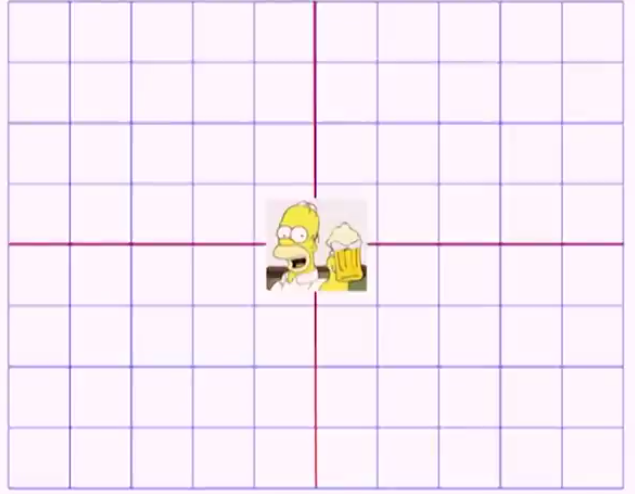

## The Drunkard's walk

- Main question: **Is there an interesting relationship between the number of steps the drunkman takes and how far the drunk is from the origin at the end of those steps?**

- If the drunk takes more steps maybe he will be further from the origin
- Or maybe since this process is random, more or less he never gets very far

In [3]:
import random

In [4]:
# first we create a Location type in order to set the rules and tools of how the drunk will move
# note how is inmutable, we never change the values, we only return new ones
class Location:
    def __init__(self, x, y):
        """
        x and y are floats
        """

        self.x = x
        self.y = y

    def move(self, deltaX, deltaY):
        """
        deltaX and deltaY are floats
        """

        return Location(self.x + deltaX, self.y + deltaY)

    def getX(self):
        return self.x

    def getY(self):
        return self.y

    def distFrom(self, other):
        """
        'other' is another location class in order to calcualte the distance to it
        """
        xDist = self.x - other.getX()
        yDist = self.y - other.getY()
        return (xDist**2 + yDist**2) ** 0.5

    def __str__(self):
        return "<" + str(self.x) + ", " + str(self.y) + ">"

In [5]:
# we create a base class to be inhertied, it will be use later to to the next drunk sublcasses
class Drunk:
    def __init__(self, name=None):
        """
        Assumes name is a str
        """
        self.name = name

    def __str__(self):
        if self.name != None:
            return self.name
        return "Anonymous"

In [6]:
# we create two types of drunks (two kinds of random walks)


class UsualDrunk(Drunk):
    """
    A drunk that can move randomly to the left, right, up or down
    """

    def takeStep(self):
        stepChoices = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        return random.choice(stepChoices)


class MasochistDrunk(Drunk):
    """
    A drunk that can move randomly, but biased upwards and to the left
    also called a biased random walk
    """

    def takeStep(self):
        stepChoices = [(0.0, 1.1), (0.0, -0.9), (1.0, 0.0), (-1.0, 0.0)]
        return random.choice(stepChoices)

In [7]:
# we creat the field type, a field will show the location of the drunks
class Field:

    def __init__(self):
        self.drunks = {}

    def addDrunk(self, drunk, loc):
        """
        If a drunk already exists, we raise an error
        If a drunk is not inlcuded, we indlude its name and its location
        """
        if drunk in self.drunks:
            raise ValueError("Duplicate Drunk")
        else:
            self.drunks[drunk] = (
                loc  # improtantt to note that "loc" is an isntance of the location class
            )

    def getLoc(self, drunk):
        if drunk not in self.drunks:
            raise ValueError("Drunk not in field")
        return self.drunks[drunk]

    def moveDrunk(self, drunk):
        """
        Once we have our drunks in their positions we would want see how they move
        Given a 'drunk' we will generate a new random movement and store those coordinates

        """
        if drunk not in self.drunks:
            raise ValueError("Drunk not in field")
        xDist, yDist = drunk.takeStep()

        # we take a random step

        self.drunks[drunk] = self.drunks[drunk].move(xDist, yDist)

        # we use the 'move' method of the Location instance to get new location
        # in order to replace the previous stored location with the new location

In [8]:
def walk(f, d, numSteps):
    """
    Creates a walk simulation of the drunk, moving the drunk in numSetps steps
    Assumes: f a field, d a drunk in f, and numSteps an int >= 0
    Returns the dinstance of the final and the initiallocation of the drunk
    """

    start = f.getLoc(d)  # we store the Location instance as a start location
    for s in range(numSteps):
        f.moveDrunk(
            d
        )  # we move the drunk n steps (remember that we are overwriting the location isntance in the 'drunks' dictionary)

    return start.distFrom(
        f.getLoc(d)
    )  # finally we calculate the distance from the initial and final locations

In [ ]:
def simWalks(numSteps, numTrials, dClass):
    """
    Assumes numSteps an int >= 0, numTrials an int > 0, dClass a subclass of Drunk
    Simulates numTrials walks of numSteps steps each

    For example, if numSteps  = 10 and numTrials = 5
    the function performs five independent 10-step walks

    Stores the final distance from the origin for each trial
    and returns a list containing those distances
    """

    Homer = dClass()
    origin = Location(0, 0)
    distances = []
    for t in range(numTrials):
        f = Field()
        f.addDrunk(Homer, origin)
        distances.append(
            round(walk(f, Homer, numTrials), 1)
        )  # note something interesting here?

    return distances

In [ ]:
def drunkTest(walkLenghts, numTrials, dClass):
    """
    Assumes walkLengths a sequence of ints >= 0
    numTrials an int > 0,
    dClass a subclass of Drunk

    For each number of steps in walkLenghts, runs simWalks with numTrials walks and print Results

    For example, if walkLengths = (10,100) , the function
    simulates numTrials walks of 10 steps, and numtrials walks of 100 steps

    Prints the mean, min and max distance of the simulated steps
    """
    # we simulate different random walks with different number of steps but the same number of trials
    for numSteps in walkLenghts:
        # we will get the list of distances of the simualtion of the respective random walk ntimes
        distances = simWalks(numSteps, numTrials, dClass)
        print(dClass.__name__, "random walk of", numSteps, "steps")

        print(" Mean =", round(sum(distances) / len(distances), 4))

        print(" Max =", max(distances), "Min =", min(distances))

In [11]:
random.seed(0)

# we want to simulate 100 walks of different steps, and our drunk will be a usual drunk (not biased)
# and calculate the mean, max and min
drunkTest((10, 100, 1000, 10000), 100, UsualDrunk)

UsualDrunk random walk of 10 steps
 Mean = 8.634
 Max = 21.6 Min = 1.4
UsualDrunk random walk of 100 steps
 Mean = 8.57
 Max = 22.0 Min = 0.0
UsualDrunk random walk of 1000 steps
 Mean = 9.206
 Max = 21.6 Min = 1.4
UsualDrunk random walk of 10000 steps
 Mean = 8.727
 Max = 23.5 Min = 1.4


1. Seems that on average, the average number of steps that our drunk moves does not change when we increase the number of steps, neither the min or max values

2. But... **Does this result look plausibile? What is telling us here?**

3. That the length of the walk does not really affect how far the drunk gets! THere is some randomness but not much variance

4. And concluding these findings, something that we shoudl always do is a **sanity check** , we want to make sure that these results make sense!

## Sanity Check

- With a **sanity check** we take a simple case where we are pretty sure that we know what the answer is!

- For this case, we analyze how the simulated resutls would be with a small nubmer of steps!

- For 0 steps the min, average and max... should be 0! For 1, should be 1, and for two may vary

In [12]:
random.seed(0)
drunkTest((0, 1, 2), 100, UsualDrunk)

UsualDrunk random walk of 0 steps
 Mean = 8.634
 Max = 21.6 Min = 1.4
UsualDrunk random walk of 1 steps
 Mean = 8.57
 Max = 22.0 Min = 0.0
UsualDrunk random walk of 2 steps
 Mean = 9.206
 Max = 21.6 Min = 1.4


- And now with these results we should be very suspiscious, why the mean is still around 8.7 if we only took 0 - 2 steps?

- Now we should review our code...

In [13]:
def simWalks(numSteps, numTrials, dClass):
    """
    Assumes numSteps an int >= 0, numTrials an int > 0, dClass a subclass of Drunk
    Simulates numTrials walks of numSteps steps each
    For example, we will simulate a 5 walk of 10 steps
    We want to repeat the walks and store the walked distance
    Returns a list of the final distances for each trial
    """

    Homer = dClass()
    origin = Location(0, 0)
    distances = []
    for t in range(numTrials):
        f = Field()
        f.addDrunk(Homer, origin)
        distances.append(
            round(walk(f, Homer, numSteps), 1)  # before it was numTrials
        )  # note something interesting here? we were  always walking numTrials steps! we are not using numSteps

    return distances

- So we were always walking 100 steps! 

- In each trial we were walking the same number of trials, that is why the results were so rare

In [14]:
random.seed(0)
drunkTest((0, 1, 2), 100, UsualDrunk)

UsualDrunk random walk of 0 steps
 Mean = 0.0
 Max = 0.0 Min = 0.0
UsualDrunk random walk of 1 steps
 Mean = 1.0
 Max = 1.0 Min = 1.0
UsualDrunk random walk of 2 steps
 Mean = 1.218
 Max = 2.0 Min = 0.0


- Now the results make totally sense! We debugged the code correctly and the simulation passed the sanitity check, we can proceed to simulate again 

In [15]:
random.seed(0)

# we want to simulate 100 walks of different steps, and our drunk will be a usual drunk (not biased)
# and calculate the mean, max and min
drunkTest((10, 100, 1000, 10000), 100, UsualDrunk)

UsualDrunk random walk of 10 steps
 Mean = 2.863
 Max = 7.2 Min = 0.0
UsualDrunk random walk of 100 steps
 Mean = 8.296
 Max = 21.6 Min = 1.4
UsualDrunk random walk of 1000 steps
 Mean = 27.297
 Max = 66.3 Min = 4.2
UsualDrunk random walk of 10000 steps
 Mean = 89.241
 Max = 226.5 Min = 10.0


- Now we see that in fact, it does appear to be that the more steps the drunk takes the further away the drunk ends up


## And the masochistic drunk?

In [16]:
random.seed(0)

# we want to simulate 100 walks of different steps, and our drunk will be a usual drunk (not biased)
# and calculate the mean, max and min
drunkTest((10, 100, 1000, 10000), 100, MasochistDrunk)

MasochistDrunk random walk of 10 steps
 Mean = 2.941
 Max = 7.4 Min = 0.4
MasochistDrunk random walk of 100 steps
 Mean = 9.24
 Max = 23.4 Min = 1.1
MasochistDrunk random walk of 1000 steps
 Mean = 53.519
 Max = 108.5 Min = 2.1
MasochistDrunk random walk of 10000 steps
 Mean = 509.872
 Max = 722.8 Min = 355.2


In [17]:
def simAll(drunkKinds, walkLengths, numTrials):
    for dClass in drunkKinds:
        drunkTest(walkLengths, numTrials, dClass)

In [18]:
random.seed(0)
simAll((UsualDrunk, MasochistDrunk), (1000, 10000), 100)

UsualDrunk random walk of 1000 steps
 Mean = 26.828
 Max = 66.3 Min = 4.2
UsualDrunk random walk of 10000 steps
 Mean = 90.073
 Max = 210.6 Min = 7.2
MasochistDrunk random walk of 1000 steps
 Mean = 58.425
 Max = 133.3 Min = 6.7
MasochistDrunk random walk of 10000 steps
 Mean = 515.575
 Max = 694.6 Min = 377.7


- What is going on?

- Given that the masochistic Drunk 1/4 of the time is moving 1.1 (0.1) more to the north and another 1/4 of the time moving -0.9 (-0.1) less to the south. the steps are baised half of the time to move towards the north (positive Y),  being further from the origin than the normal drunk



### Plotting the results

- The objetive is to use plots to help us to understand data

In [19]:
import pylab

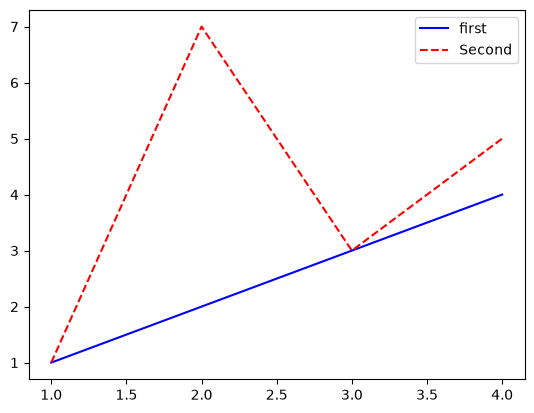

In [20]:
xVals = [1, 2, 3, 4]
yVals1 = [1, 2, 3, 4]
pylab.plot(xVals, yVals1, "b-", label="first")
yVals2 = [1, 7, 3, 5]
pylab.plot(xVals, yVals2, "r--", label="Second")
pylab.legend()

In [69]:
class styleIterator:
    """
    Helper to change the style of the plot
    Amits a list of possible styles to iterate through
    """

    def __init__(self, styles):
        self.index = 0
        self.styles = styles

    def nextStyle(self):
        result = self.styles[self.index]
        if self.index == len(self.styles) - 1:
            self.index = 0
        else:
            self.index += 1
        return result


def simDrunk(numTrials, dClass, walkLengths):
    """
    - Function to simulate several drunk walks (random walks)
    - The difference between this function and 'drunkTest' is that the previous one
    - helped us to print important metrics (mean, min max) of trials with different steps
    - Now we want to store only the mean of the trials in a list to use it later to plot
    """
    meanDistances = []
    for numSteps in walkLengths:
        print("Starting simulation of", numSteps, "steps")
        trials = simWalks(numSteps, numTrials, dClass)
        mean = sum(trials) / len(trials)
        meanDistances.append(mean)

    return meanDistances


def simAll(drunkKinds, walkLengths, numTrials):
    """
    We update this function in order to add more features:

        - Before the function only compared usualdrunk steps and masochisticDrunk steps
        - Now can con plot the results given a list of styles to iterate
        - We get the distance means of drunk walks with the previous function
        - Finally we are plotting the results, with the X axis as the different walkLenghts
        - and the respective distance means of those experiments
        - The objective is to visually understand how the distances change as we increase the number of steps in the experiments
    """
    styleChoice = styleIterator(("m-", "b--", "g-."))
    for dClass in drunkKinds:
        curStyle = styleChoice.nextStyle()
        print("Starting simulation of ", dClass.__name__)
        means = simDrunk(numTrials, dClass, walkLengths)
        pylab.plot(walkLengths, means, curStyle, label=dClass.__name__)

    pylab.title("Mean distance from Origin (" + str(numTrials) + "trials)")
    pylab.xlabel("Number of Steps")
    pylab.ylabel("Distance from Origin")
    pylab.legend(loc="best")

Starting simulation of  UsualDrunk
Starting simulation of 10 steps
Starting simulation of 100 steps
Starting simulation of 1000 steps
Starting simulation of 10000 steps
Starting simulation of 100000 steps
Starting simulation of  MasochistDrunk
Starting simulation of 10 steps
Starting simulation of 100 steps
Starting simulation of 1000 steps
Starting simulation of 10000 steps
Starting simulation of 100000 steps


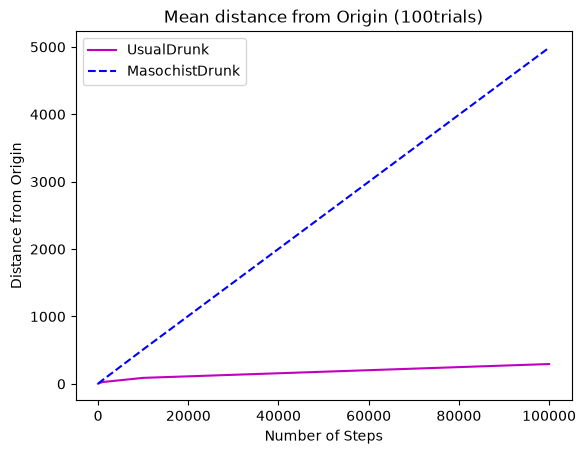

In [70]:
random.seed(0)
# we want to simulate how  would be the average distance of the walks with 10 - 100,000 steps
# for two kinds of drunks (the biased and the usual)
numSteps = (10, 100, 1000, 10000, 100000)
simAll((UsualDrunk, MasochistDrunk), numSteps, 100)

- We can see how the usual drunk (purple) slowly walks away from the starting point
- While the masochistic drunk is considerable faster
- It look like the usual drukn is moving at abuot the square root of the number of steps
- And it makes sense since the distance is calculated using the pithagorean formula

- On the other hand, the masochistic drunk seems to be movign a rate of numSteps times 0.05 (5%)
- As we said there is a slight difference in the walks between the usual and masochistic drunk to the north and the south (half of the time the steps are diverging by a small fraction)
- At a rate of 0.1! and if this divergence is occuring 1/2 of time, the diverge ends with 0.05...

Starting simulation of  UsualDrunk
Starting simulation of 10 steps
Starting simulation of 100 steps
Starting simulation of 1000 steps
Starting simulation of 10000 steps
Starting simulation of 100000 steps
Starting simulation of  MasochistDrunk
Starting simulation of 10 steps
Starting simulation of 100 steps
Starting simulation of 1000 steps
Starting simulation of 10000 steps
Starting simulation of 100000 steps


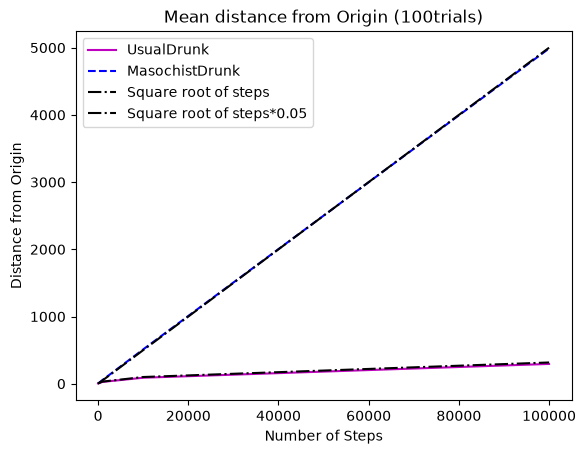

In [73]:
random.seed(0)
numSteps = (10, 100, 1000, 10000, 100000)
# now we can check our theory, adding to the plot the square root of the number of steps
simAll((UsualDrunk, MasochistDrunk), numSteps, 100)
pylab.plot(numSteps, pylab.array(numSteps) ** 0.5, "k-.", label="Square root of steps")
pylab.plot(
    numSteps, pylab.array(numSteps) * 0.05, "k-.", label="Square root of steps*0.05"
)
pylab.legend(loc="best")

- **In deed**! it is not exactly but the average distance of the usual drunk seems to be pretty similar to the square root of the number of steps

- **And for the masochistic drunk**, our hypothesis was correct, the line of the num of walks tiems 0.05 lies almost exactly in the same place of the masochistic drunk's line

In [78]:
class OddField(Field):
    """
    We inheret the field class in order to add new features

    1. First we create the wormholes dictionary, where we map specific positions in the field with new random ones
    2, Then, we imitate the original Field random movement
    3. But if the new position is already mapped in wormholes, we teleportate our drunk to other position
    """

    def __init__(self, numHoles=1000, xRange=100, yRange=100):
        Field.__init__(
            self
        )  # here we run the original Field intance setup and THEN the new code
        self.wormholes = {}
        for w in range(numHoles):
            x = random.randint(-xRange, xRange)
            y = random.randint(-yRange, yRange)
            newX = random.randint(-xRange, xRange)
            newY = random.randint(-yRange, yRange)
            newLoc = Location(newX, newY)
            self.wormholes[(x, y)] = newLoc

    def moveDrunk(self, drunk):
        Field.moveDrunk(
            self, drunk
        )  # we first call the original method to move randomly the drunk
        x = self.drunks[drunk].getX()
        y = self.drunks[drunk].getY()
        if (x, y) in self.wormholes:
            self.drunks[drunk] = self.wormholes[
                (x, y)
            ]  # and nwo we add an special behavior


def getFinalLocs(numSteps, numTrials, dClass):
    """
    Function to simulate different walks for a given type of drunk
    Returns a list of the final locations of those indpendent trials
    """
    locs = []
    d = dClass()
    for t in range(numTrials):
        f = OddField()
        f.addDrunk(d, Location(0, 0))
        for s in range(numSteps):
            f.moveDrunk(d)
        locs.append(f.getLoc(d))
    return locs


def plotLocs(drunkKinds, numSteps, numTrials):
    styleChoice = styleIterator(("k+", "r^", "mo"))
    for dClass in drunkKinds:

        locs = getFinalLocs(numSteps, numTrials, dClass)

        xVals, yVals = [], []

        for loc in locs:

            xVals.append(loc.getX())
            yVals.append(loc.getY())

        xVals = pylab.array(xVals)
        yVals = pylab.array(yVals)
        meanX = sum(abs(xVals)) / len(xVals)
        meanY = sum(abs(yVals)) / len(yVals)
        curStyle = styleChoice.nextStyle()
        pylab.plot(
            xVals,
            yVals,
            curStyle,
            label=dClass.__name__
            + "mean abs dist = <"
            + str(meanX)
            + ", "
            + str(meanY)
            + ">",
        )

    pylab.title("Location at End of Walks (" + str(numSteps) + " steps)")
    pylab.ylim(-1000, 1000)
    pylab.xlim(-1000, 1000)
    pylab.xlabel("Steps East/West of Origin")
    pylab.ylabel("Steps North/South of Origin")
    pylab.legend(loc="lower center")

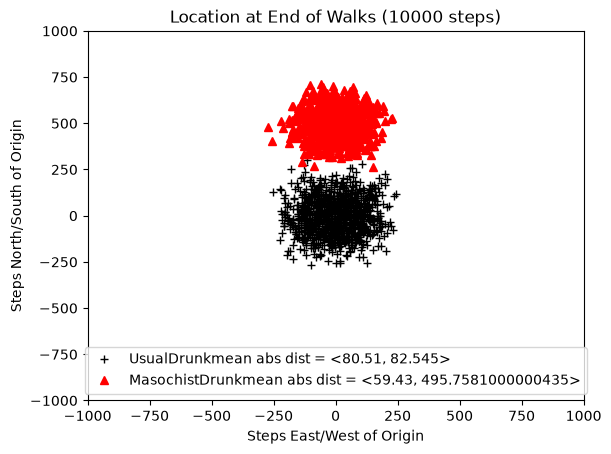

In [79]:
random.seed(0)
# here we want to plot the final positions of the drunks of 1000 experiments of 10,000 random walks
plotLocs((UsualDrunk, MasochistDrunk), 10000, 1000)

- As we mentioend before, the East/West steps behave similar in both kinds of Drunks

- But there is a huge difference in the South/North steps, in the plots and in the average distance

In [ ]:
def traceWalk(fieldKinds, numSteps):
    styleChoice = styleIterator(("b+", "r^", "ko"))
    for fClass in fieldKinds:
        d = UsualDrunk()
        f = fClass()
        f.addDrunk(d, Location(0, 0))
        locs = []
        for s in range(numSteps):
            f.moveDrunk(d)
            locs.append(f.getLoc(d))
        xVals, yVals = [], []
        for loc in locs:
            xVals.append(loc.getX())
            yVals.append(loc.getY())
        curStyle = styleChoice.nextStyle()
        pylab.plot(xVals, yVals, curStyle, label=fClass.__name__)

    pylab.title("Spots Visited on walk (" + str(numSteps) + " steps")
    pylab.ylabel("Steps East/West of Origin")
    pylab.xlabel("Steps North/South of Origin")
    pylab.legend(loc="best")

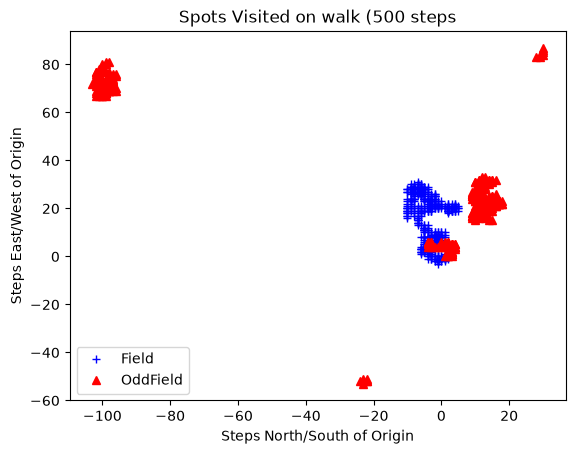

In [80]:
random.seed(9)
traceWalk((Field, OddField), 500)

# Conclusions

- The point is not only the simulations but how we built them
- We started defining the classes
- The we built functions corresponding to one trial, multiplie trials, different drunks...
- We make sanaity checks to debug our simulations
- And then we made different changes to the simulation to investigate different questions!
- The simple question was: how a simple drunk behaves in a simple field? with great insights
- But we tried with a different kind of druk and a different kind of field
- And how plotting helps to understand the data and resutls of our simulations